# K-means Clustering and Selecting Informative Bands


1. Loads PCA/global preprocessing objects from `global_stats.npz`.
2. Uses the balanced mask-based sample from the paper methodology: 50,000 pixels per class.
3. Builds standardized feature matrices for:
   - 7 detected wavelength peaks,
   - PCA5,
   - the full 430-band dataset.
4. Runs K-means on the full balanced sampled set for each feature set.



In [24]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr
from tqdm import tqdm
from scipy.signal import find_peaks
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    jaccard_score,
    precision_recall_fscore_support,
)


data_dir = Path("../data/SA1_K4")
HDR_PATH = data_dir / "MOZ/SA1_K4_HS_MOZ.hdr"
DAT_PATH = data_dir / "MOZ/SA1_K4_HS_MOZ.dat"

ZARR_PATH = data_dir / "SA1_K4_HS_MOZ.zarr"
ZARR_META_PATH = data_dir / "SA1_K4_HS_MOZ.zarr_metadata.json"

RGB_PATH = Path("../masks/.rgb_reference.png")
MASK_PATH = Path("../masks/class_mask.npy")

cache_dir = Path("../data/cache")
cache_dir.mkdir(parents=True, exist_ok=True)

GLOBAL_STAT_PATH = cache_dir / "global_stats.npz"
RF_INPUTS_PATH = cache_dir / "rf_inputs.npz"
KMEANS_RESULTS_PATH = cache_dir / "kmeans_results.npz"

# Class convention used by the mask labels.
CLASS_IDS = np.array([1, 2, 3, 4], dtype=np.uint8)
CLASS_NAMES = {
    1: "water",
    2: "soil",
    3: "canopy",
    4: "grass",
}
z = zarr.open(str(ZARR_PATH), mode="r")
rows, cols, bands = z.shape
chunk_y, chunk_x, chunk_b = z.chunks
wavelengths = np.asarray(z.attrs["wavelength"], dtype=np.float32)

print("Zarr shape:", z.shape)
print("Zarr chunks:", z.chunks)
print("Bands:", bands)



Zarr shape: (6896, 5496, 430)
Zarr chunks: (512, 512, 16)
Bands: 430


Load `global_stats.npz`



In [28]:
# ============================================================
# Load everything from global_stats.npz
# Assumes global_stats.npz already contains all required arrays
# ============================================================

cache = np.load(GLOBAL_STAT_PATH)

# Global standardization + PCA info
global_mean = cache["global_mean"].astype(np.float32)
global_std = cache["global_std"].astype(np.float32)
global_std[global_std < 1e-8] = 1.0

Vt = cache["pca_components_Vt"].astype(np.float32)
pca_center_mean = cache["pca_center_mean"].astype(np.float32)

# Balanced sampled pixels
sample_rows = cache["sample_rows"].astype(np.int32)
sample_cols = cache["sample_cols"].astype(np.int32)
y_sample = cache["sample_labels"].astype(np.uint8)

# Full-band sampled spectra
X_full_raw = cache["X_labeled_sample_raw"].astype(np.float32)
X_full_std = cache["X_labeled_sample_standardized"].astype(np.float32)

print("Loaded global_stats.npz")
print("global_mean:", global_mean.shape)
print("global_std:", global_std.shape)
print("Vt:", Vt.shape)
print("pca_center_mean:", pca_center_mean.shape)

print("sample_rows:", sample_rows.shape)
print("sample_cols:", sample_cols.shape)
print("y_sample:", y_sample.shape)

print("X_full_raw:", X_full_raw.shape)
print("X_full_std:", X_full_std.shape)

print("\nClass counts:")
for class_id in CLASS_IDS:
    print(f"{CLASS_NAMES[int(class_id)]}: {int(np.sum(y_sample == class_id)):,}")

Loaded global_stats.npz
global_mean: (430,)
global_std: (430,)
Vt: (430, 430)
pca_center_mean: (430,)
sample_rows: (200000,)
sample_cols: (200000,)
y_sample: (200000,)
X_full_raw: (200000, 430)
X_full_std: (200000, 430)

Class counts:
water: 50,000
soil: 50,000
canopy: 50,000
grass: 50,000


### Compute wavelength peaks

This uses the balanced mask-based sample. The score is computed from raw reflectance class means.


First 7 selected wavelength peaks:
   band_index  wavelength_um  distance_score
0          31        0.51525        0.046271
1          85        0.68783        0.168608
2         143        0.87319        0.831651
3         184        1.06772        1.000000
4         226        1.29550        0.696249
5         296        1.67513        0.436453
6         364        2.04392        0.366885
Number selected: 7


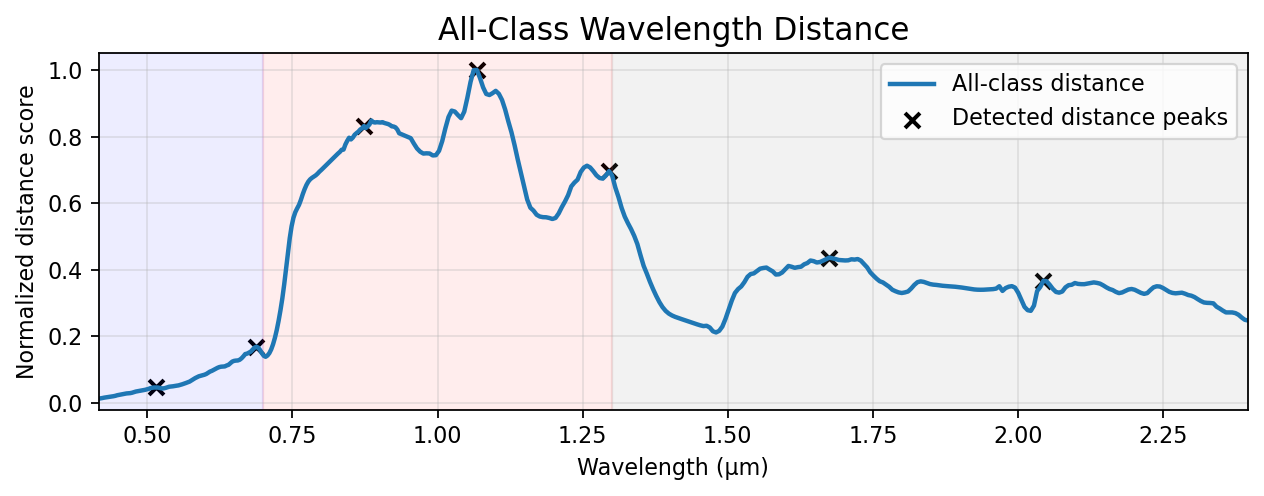

In [34]:
mean_water = X_full_raw[y_sample == 1].mean(axis=0)
mean_soil = X_full_raw[y_sample == 2].mean(axis=0)
mean_canopy = X_full_raw[y_sample == 3].mean(axis=0)
mean_grass = X_full_raw[y_sample == 4].mean(axis=0)

# Pairwise class distance score.
distance_score = (
    (mean_water - mean_soil) ** 2 +
    (mean_water - mean_canopy) ** 2 +
    (mean_water - mean_grass) ** 2 +
    (mean_soil - mean_canopy) ** 2 +
    (mean_soil - mean_grass) ** 2 +
    (mean_canopy - mean_grass) ** 2
)

# Normalize score from 0 to 1.
distance_score = distance_score / distance_score.max()

# Detect local maxima.
peaks, _ = find_peaks(
    distance_score,
    prominence=0.002,
    distance=40,
)

peak_table = pd.DataFrame({
    "band_index": peaks,
    "wavelength_um": wavelengths[peaks],
    "distance_score": distance_score[peaks],
}).sort_values("wavelength_um")

# First 7 peaks by wavelength order.
first7_selected = peak_table.head(7).sort_values("band_index")
FIRST7_SELECTED_BANDS = first7_selected["band_index"].to_numpy(dtype=np.int32)
first7_selected_wavelengths = first7_selected["wavelength_um"].to_numpy(dtype=np.float32)

print("First 7 selected wavelength peaks:")
print(first7_selected)
print("Number selected:", len(FIRST7_SELECTED_BANDS))

plt.figure(figsize=(8, 3.2), dpi=160)

# Main curve
plt.plot(
    wavelengths,
    distance_score,
    linewidth=2,
    label="All-class distance"
)

# Detected peaks
plt.scatter(
    wavelengths[peaks],
    distance_score[peaks],
    marker="x",
    s=45,
    color="black",
    linewidths=1.8,
    label="Detected distance peaks"
)

# Spectral regions
plt.axvspan(0.4, 0.7, color="blue", alpha=0.07)
plt.axvspan(0.7, 1.3, color="red", alpha=0.07)
plt.axvspan(1.3, 2.5, color="gray", alpha=0.10)

# Labels and title
plt.title("All-Class Wavelength Distance", fontsize=14)
plt.xlabel("Wavelength (μm)")
plt.ylabel("Normalized distance score")

# Axes
plt.xlim(wavelengths.min(), wavelengths.max())
plt.ylim(-0.02, 1.05)

# Grid and legend
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Building feature matrices
Based on all 430 Bands, top 5 PCs, and 7 selected bands. 

In [9]:
# Selected 7-band feature set from the first 7 wavelength peaks in section 4.
X_first7_selected_std = X_full_std[:, FIRST7_SELECTED_BANDS].astype(np.float32)

# PCA5 features.
if "X_pca5" in cache.files:
    X_pca5_raw = cache["X_pca5"].astype(np.float32)
    print("Loaded X_pca5 from global_stats.npz")
else:
    print("X_pca5 not found. Computing PCA5 from pca_components_Vt and pca_center_mean.")
    X_pca5_raw = ((X_full_std - pca_center_mean) @ Vt[:5].T).astype(np.float32)

# Standardize PCA scores for consistent model scaling.
X_pca5_std, pca5_score_mean, pca5_score_std = standardize_columns(X_pca5_raw)

print("X_first7_selected_std:", X_first7_selected_std.shape)
print("X_pca5_std:", X_pca5_std.shape)
print("X_full_std:", X_full_std.shape)


Loaded X_pca5 from global_stats.npz
X_first7_selected_std: (200000, 7)
X_pca5_std: (200000, 5)
X_full_std: (200000, 430)


## K-means clustering

K-means is run on the full balanced sampled dataset. Each cluster is mapped to the ground-truth class by maximum overlap using the mask labels.


In [ ]:

# K-means helper functions

KMEANS_RANDOM_STATE = 42
KMEANS_N_CLUSTERS = len(CLASS_IDS)


def map_clusters_to_classes(y_true, clusters, class_ids):
    """Map K-means cluster IDs to class IDs by maximum total overlap."""
    cluster_ids = np.sort(np.unique(clusters))

    # count_matrix[class_index, cluster_index]
    count_matrix = np.zeros((len(class_ids), len(cluster_ids)), dtype=np.int64)

    for i, class_id in enumerate(class_ids):
        for j, cluster_id in enumerate(cluster_ids):
            count_matrix[i, j] = np.sum((y_true == class_id) & (clusters == cluster_id))

    # Hungarian assignment maximizes total overlap by minimizing negative counts.
    row_ind, col_ind = linear_sum_assignment(-count_matrix)

    cluster_to_class = {}
    for r, c in zip(row_ind, col_ind):
        cluster_to_class[int(cluster_ids[c])] = int(class_ids[r])

    # Safety fallback if any cluster was not assigned.
    for cluster_id in cluster_ids:
        cluster_id_int = int(cluster_id)
        if cluster_id_int not in cluster_to_class:
            j = np.where(cluster_ids == cluster_id)[0][0]
            best_class_index = int(np.argmax(count_matrix[:, j]))
            cluster_to_class[cluster_id_int] = int(class_ids[best_class_index])

    y_pred = np.array([cluster_to_class[int(c)] for c in clusters], dtype=np.uint8)

    return y_pred, cluster_to_class, count_matrix


def evaluate_classification(y_true, y_pred, class_ids, class_names):
    conf = confusion_matrix(y_true, y_pred, labels=class_ids)
    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=class_ids,
        zero_division=0,
    )

    iou = jaccard_score(
        y_true,
        y_pred,
        labels=class_ids,
        average=None,
        zero_division=0,
    )

    per_class = pd.DataFrame({
        "class_id": class_ids.astype(np.int32),
        "class_name": [class_names[int(c)] for c in class_ids],
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou,
        "support": support,
    })

    summary = {
        "accuracy": float(accuracy),
        "macro_f1": float(np.mean(f1)),
        "mean_iou": float(np.mean(iou)),
    }

    return conf, per_class, summary


def run_kmeans_feature_set(feature_name, X, y_true):

    kmeans = KMeans(
        n_clusters=KMEANS_N_CLUSTERS,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=KMEANS_RANDOM_STATE,
        algorithm="lloyd",
    )

    clusters = kmeans.fit_predict(X).astype(np.int32)
    y_pred, cluster_to_class, cluster_count_matrix = map_clusters_to_classes(
        y_true=y_true,
        clusters=clusters,
        class_ids=CLASS_IDS,
    )

    conf, per_class, summary = evaluate_classification(
        y_true=y_true,
        y_pred=y_pred,
        class_ids=CLASS_IDS,
        class_names=CLASS_NAMES,
    )

    return {
        "feature_name": feature_name,
        "clusters": clusters,
        "y_pred": y_pred,
        "confusion_matrix": conf,
        "per_class": per_class,
        "summary": summary,
        "cluster_centers": kmeans.cluster_centers_.astype(np.float32),
        "cluster_to_class": cluster_to_class,
        "cluster_count_matrix": cluster_count_matrix,
        "inertia": float(kmeans.inertia_),
        "n_iter": int(kmeans.n_iter_),
    }


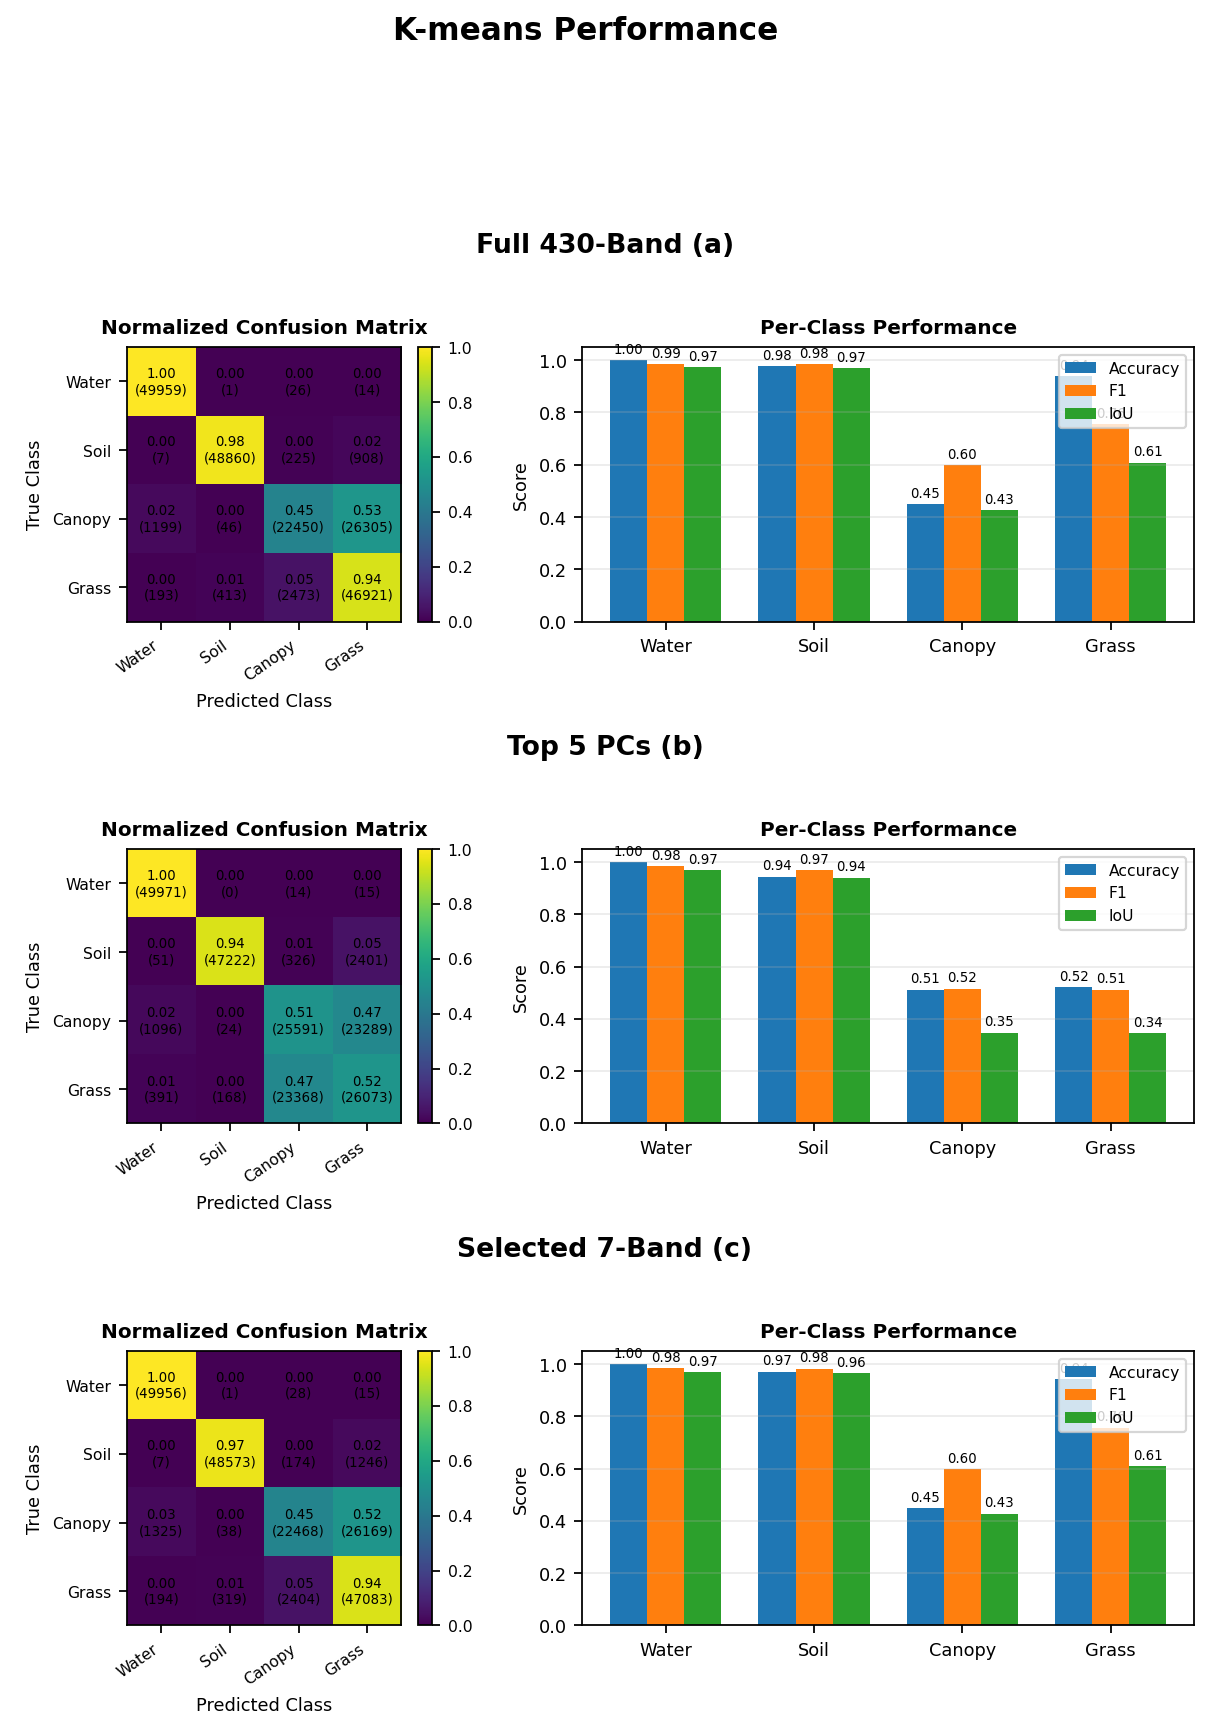

In [ ]:
# Run K-means on each feature set using the full balanced sample

kmeans_results = {}

feature_sets = {
    "first7_selected": X_first7_selected_std,
    "pca5": X_pca5_std,
    "full430": X_full_std,
}

for feature_name, X_features in feature_sets.items():
    kmeans_results[feature_name] = run_kmeans_feature_set(
        feature_name=feature_name,
        X=X_features,
        y_true=y_sample,
    )

summary_rows = []
per_class_rows = []

for feature_name, result in kmeans_results.items():
    summary_rows.append({
        "model": "KMeans",
        "feature_set": feature_name,
        "num_features": int(feature_sets[feature_name].shape[1]),
        "samples": int(len(y_sample)),
        "accuracy": result["summary"]["accuracy"],
        "macro_f1": result["summary"]["macro_f1"],
        "mean_iou": result["summary"]["mean_iou"],
        "inertia": result["inertia"],
        "n_iter": result["n_iter"],
    })

    temp = result["per_class"].copy()
    temp.insert(0, "feature_set", feature_name)
    per_class_rows.append(temp)

kmeans_summary_df = pd.DataFrame(summary_rows)
kmeans_per_class_df = pd.concat(per_class_rows, ignore_index=True)


plot_items = list(kmeans_results.items())

row_titles = [
    "Full 430-Band (a)",
    "Top 5 PCs (b)",
    "Selected 7-Band (c)"
]

class_labels = [CLASS_NAMES[int(c)].title() for c in CLASS_IDS]


fig = plt.figure(figsize=(9.5, 11.5), dpi=160)

gs = GridSpec(
    nrows=6,
    ncols=2,
    figure=fig,
    height_ratios=[0.18, 1, 0.18, 1, 0.18, 1],
    width_ratios=[1.0, 1.45],
    hspace=0.55,
    wspace=0.28
)

fig.suptitle("K-means Performance", fontsize=14, fontweight="bold", y=0.985)

for row_idx, ((name, result), row_title) in enumerate(zip(plot_items, row_titles)):

    title_row = row_idx * 2
    plot_row = title_row + 1


    ax_title = fig.add_subplot(gs[title_row, :])
    ax_title.axis("off")
    ax_title.text(
        0.5,
        0.25,
        row_title,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )


    conf = result["confusion_matrix"]

    conf_norm = np.divide(
        conf,
        conf.sum(axis=1, keepdims=True),
        out=np.zeros_like(conf, dtype=float),
        where=conf.sum(axis=1, keepdims=True) != 0
    )

    ax_conf = fig.add_subplot(gs[plot_row, 0])

    im = ax_conf.imshow(conf_norm, vmin=0, vmax=1)

    ax_conf.set_title("Normalized Confusion Matrix", fontsize=9, fontweight="bold")
    ax_conf.set_xlabel("Predicted Class", fontsize=8)
    ax_conf.set_ylabel("True Class", fontsize=8)

    ax_conf.set_xticks(np.arange(len(CLASS_IDS)))
    ax_conf.set_yticks(np.arange(len(CLASS_IDS)))
    ax_conf.set_xticklabels(class_labels, rotation=35, ha="right", fontsize=7)
    ax_conf.set_yticklabels(class_labels, fontsize=7)

    for i in range(len(CLASS_IDS)):
        for j in range(len(CLASS_IDS)):
            ax_conf.text(
                j,
                i,
                f"{conf_norm[i, j]:.2f}\n({conf[i, j]})",
                ha="center",
                va="center",
                fontsize=6
            )

    cbar = fig.colorbar(im, ax=ax_conf, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=7)


    ax_bar = fig.add_subplot(gs[plot_row, 1])

    per_class = result["per_class"]

    x = np.arange(len(per_class))
    width = 0.25

    accuracy = per_class["recall"].to_numpy()
    f1 = per_class["f1"].to_numpy()
    iou = per_class["iou"].to_numpy()
    class_names_plot = per_class["class_name"].str.title().to_numpy()

    ax_bar.bar(x - width, accuracy, width, label="Accuracy")
    ax_bar.bar(x, f1, width, label="F1")
    ax_bar.bar(x + width, iou, width, label="IoU")

    ax_bar.set_title("Per-Class Performance", fontsize=9, fontweight="bold")
    ax_bar.set_ylabel("Score", fontsize=8)
    ax_bar.set_ylim(0, 1.05)

    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(class_names_plot, fontsize=8)

    ax_bar.tick_params(axis="y", labelsize=8)
    ax_bar.grid(axis="y", alpha=0.25)
    ax_bar.legend(fontsize=7, loc="upper right")

    for offset, values in [(-width, accuracy), (0, f1), (width, iou)]:
        for i, val in enumerate(values):
            ax_bar.text(
                i + offset,
                val + 0.015,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=6
            )

plt.show()
